<a href="https://colab.research.google.com/github/Narlemus/telecomx-churn-prediction_II_AluraChallenge/blob/main/SOLUCI%C3%93N_CHALLENGE_II_TELECOM_TX_II_LNL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Telecom X — Parte 2: Predicción de Churn**



# 1️⃣ **Importación de librerías**

Primera celda del notebook:

In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
# Librerías de Machine Learning (de scikit-learn):

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2️⃣**Cargar el dataset limpio de la Parte 1**

Se exporta dataset con los datos limpiados:

In [69]:
# Cargamos el Dataset

df = pd.read_csv("telecomx_churn_clean.csv")

df.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_Meses,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo_Contrato,PaperlessBilling,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


Revisamos la estructura del dataset

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   float64
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   Antiguedad_Meses  7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   int64  
 11  OnlineBackup      7267 non-null   int64  
 12  DeviceProtection  7267 non-null   int64  
 13  TechSupport       7267 non-null   int64  
 14  StreamingTV       7267 non-null   int64  
 15  StreamingMovies   7267 non-null   int64  
 16  Tipo_Contrato     7267 non-null   object 


In [71]:
# Revisamos las columnas

df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Antiguedad_Meses', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Tipo_Contrato',
       'PaperlessBilling', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total',
       'Cuentas_Diarias'],
      dtype='object')

In [72]:
df.isnull().sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Antiguedad_Meses,0
PhoneService,0
MultipleLines,0
InternetService,0


Ver la variable objetivo (Churn)

Esta es la variable que el modelo debe predecir.

In [73]:
df["Churn"].value_counts()

,count
Churn,
0.0,5174
1.0,1869


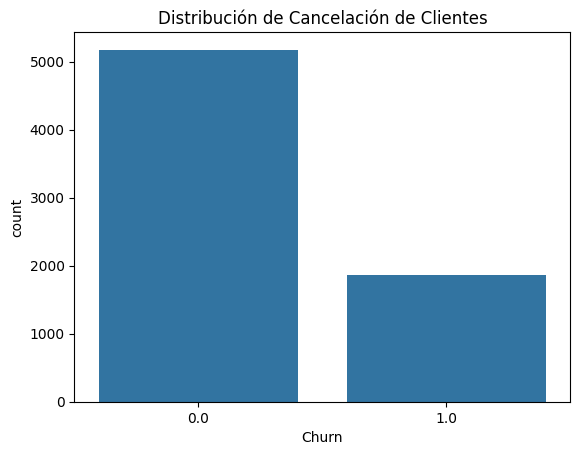

In [74]:
# También para visualizarlo  visualizarlo:

sns.countplot(x="Churn", data=df)

plt.title("Distribución de Cancelación de Clientes")
plt.show()

In [76]:
# ELIMINAMOS LAS COLUMNAS QUE NO SIRVEN PARA EL MODELO

# El ID del cliente no aporta información para predecir

df = df.drop("customerID", axis=1)


In [77]:
# CONVERSIÓN A VARIABLES CATEGÓRICAS

# Los modelos solo entienden variables numericas

df = pd.get_dummies(df, drop_first=True)

# ==> Esto convertirá columnas como:

# * Contract
# * InternetService
# * PaymentMethod

# en variables numéricas.

In [78]:
# VERIFICAMOS QUE NO EXISTAN VALORES FALTANTES

df.isnull().sum()

,0
Churn,224
SeniorCitizen,0
Partner,0
Dependents,0
Antiguedad_Meses,0
PhoneService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0


In [79]:
# Si apareve algún valor

df = df.dropna()

# SEPARAMOS EN VARIABLES PREDICTORIAS Y OBJETIVO


In [80]:

# VARIABLES PREDICTORIAS:

X = df.drop("Churn", axis=1)

In [81]:
# VARIABLES OBJETIVO:

y = df["Churn"]

# Dividir los datos en entrenamiento y prueba

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Esto divide:

#80 % entrenamiento
# 20 % prueba

# Normalización de variables

In [83]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ✅ **Verificación final antes de entrenar modelos**

In [85]:
X_train.shape

(5634, 24)

In [86]:
# Luego verifica que no existan NaN:

import numpy as np

np.isnan(X_train).sum()

## SI DEVUELVE CERO COMO RESULTADO, EL DATASET YA ESTA LISTO PARA ENTRENAR MODELOS

,0
SeniorCitizen,0
Partner,0
Dependents,0
Antiguedad_Meses,0
PhoneService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0
StreamingTV,0


# **Conclusión – Preparación de Datos para el Modelado**

---

==>  primera etapa del desafío se realizó el proceso de preparación del dataset para su uso en modelos de Machine Learning. Inicialmente se cargó y exploró el conjunto de datos limpio de Telecom X, revisando su estructura, tipos de datos y posibles valores faltantes.

* Posteriormente se identificaron las variables relevantes para el análisis, eliminando columnas que no aportan valor predictivo al modelo, como el identificador único del cliente (customerID). Luego se transformaron las variables categóricas en variables numéricas mediante técnicas de codificación, permitiendo que los algoritmos de aprendizaje automático puedan procesarlas correctamente.

* También se verificó la existencia de valores nulos y se aplicaron las acciones necesarias para garantizar la consistencia de los datos. Finalmente, el dataset se dividió en conjuntos de entrenamiento y prueba, lo cual permitirá evaluar el desempeño de los modelos de manera objetiva. Adicionalmente, se aplicó un proceso de normalización para escalar las variables numéricas y mejorar el rendimiento de ciertos algoritmos.

Como resultado, se obtuvo un conjunto de datos estructurado, limpio y listo para la fase de modelado predictivo. Este proceso es fundamental para asegurar que los modelos puedan aprender patrones relevantes y generar predicciones confiables sobre la probabilidad de cancelación de los clientes.

# **PARTE II: Correlación y Selección de Variables**

---



1️⃣ Matriz de correlación

Primero analizamos cómo se relacionan las variables numéricas.

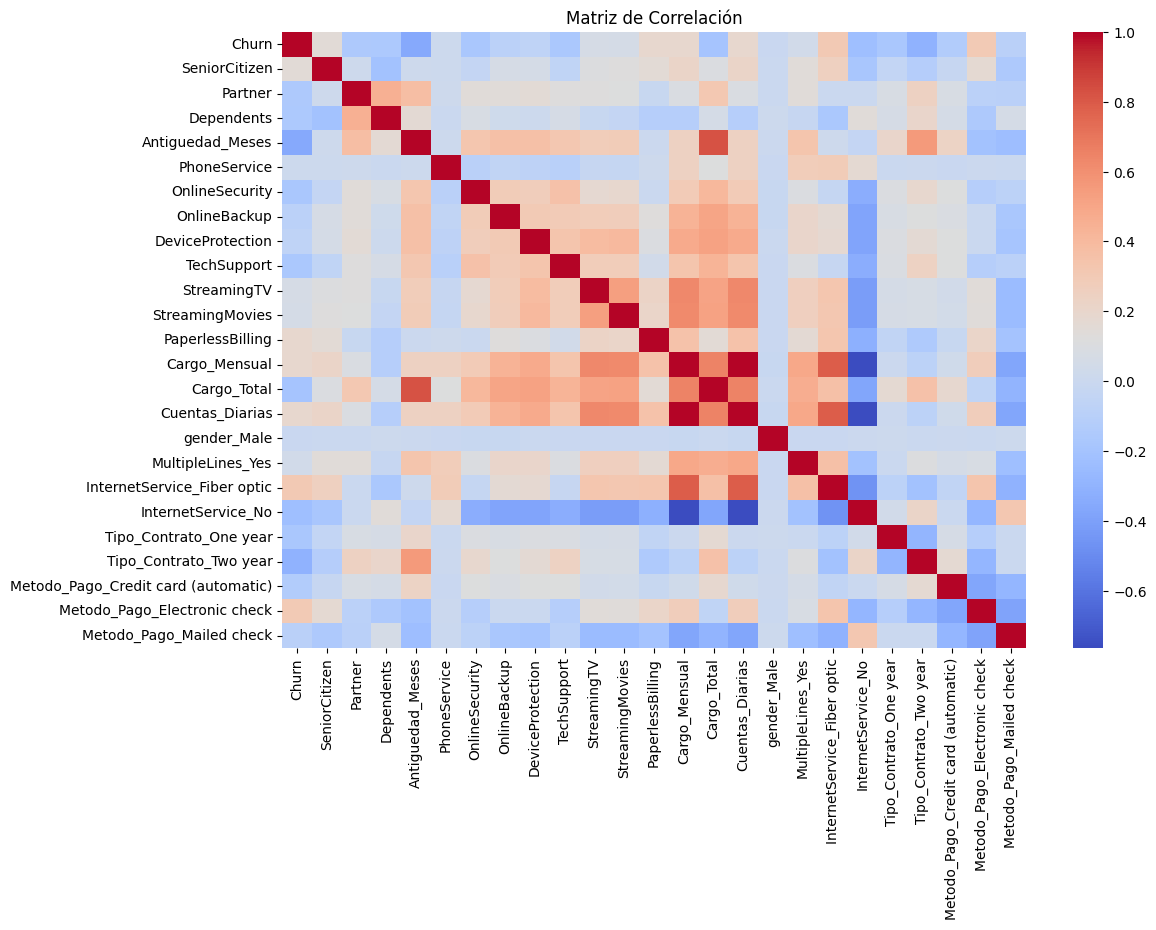

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
Metodo_Pago_Electronic check,0.301919
Cargo_Mensual,0.193356
Cuentas_Diarias,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV,0.063228
StreamingMovies,0.061382
MultipleLines_Yes,0.040102


In [91]:
correlation = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=False, cmap="coolwarm")

plt.title("Matriz de Correlación")
plt.show()

# Usare este parametro para verlas organizadas:

correlation["Churn"].sort_values(ascending=False)

La matriz de correlación permite identificar qué variables tienen mayor relación con la cancelación de clientes (Churn). Variables como el tipo de contrato, los cargos mensuales y la antigüedad del cliente muestran una relación relevante con la cancelación, lo que las convierte en candidatas importantes para los modelos predictivos.

# 2️⃣ **Análisis dirigido**


Tiempo de contrato vs Cancelación

**Interpretación esperada**

Generalmente los clientes que cancelan tienen menor tiempo de permanencia.

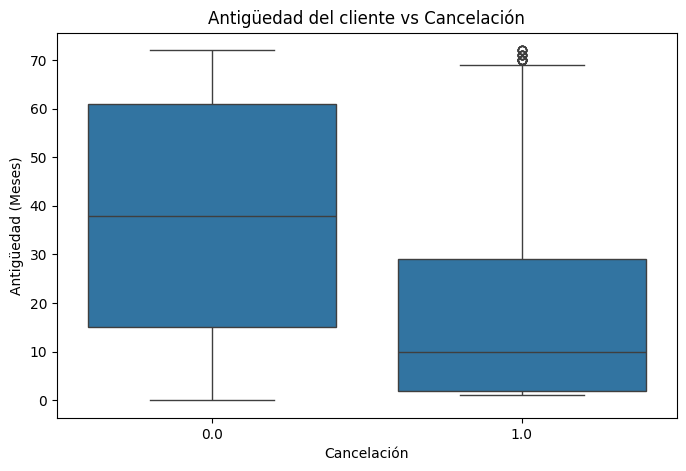

In [96]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="Antiguedad_Meses", data=df)

plt.title("Antigüedad del cliente vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Antigüedad (Meses)")

plt.show()

Se observa lo siguiente:

Generalmente:

* clientes que cancelan → menor antigüedad

* clientes que permanecen → más meses en la empresa

Esto sugiere que los clientes nuevos tienen mayor probabilidad de cancelar.

# 2️⃣ **Gasto total vs Cancelación**

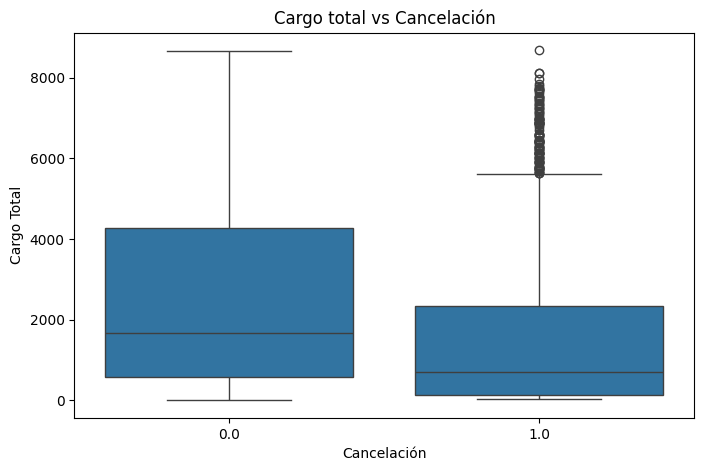

In [97]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="Cargo_Total", data=df)

plt.title("Cargo total vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Cargo Total")

plt.show()

# 3️⃣ **Gasto mensual vs Cancelación (extra útil)**

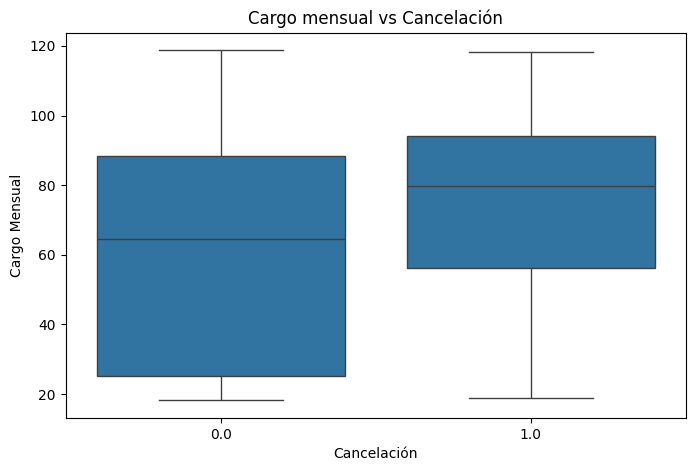

In [98]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="Cargo_Mensual", data=df)

plt.title("Cargo mensual vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Cargo Mensual")

plt.show()

# 🧠 **Interpretación:**


**Antigüedad vs Cancelación**

* Se observa que los clientes que cancelan el servicio suelen tener menor antigüedad en la empresa. Esto sugiere que los primeros meses de servicio son críticos para la retención del cliente.

--

**Cargo Total vs Cancelación**

* Los clientes que permanecen más tiempo en la empresa tienden a tener cargos totales mayores, lo que es consistente con su mayor tiempo de permanencia.

# **3️⃣ Separación de datos**

In [99]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 4️⃣ **Normalización**

Esto solo se aplica para modelos sensibles a escala como

* Logistic Regression o KNN.

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

La normalización permite que todas las variables tengan la misma escala, evitando que aquellas con valores más grandes dominen el proceso de aprendizaje del modelo.

# **5️⃣ Creación de modelos**

# **Modelo 1 - Regresión logística**

In [101]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

# **Modelo 2 - Árbol de decisión**

In [102]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(random_state=42)

model_tree.fit(X_train, y_train)

y_pred_tree = model_tree.predict(X_test)

# **6️⃣ Evaluación de modelos**

Debes mostrar métricas con scikit-learn:

In [103]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Accuracy**

In [104]:
accuracy_score(y_test, y_pred_lr)

0.8062455642299503

**Reporte completo**

In [105]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1036
         1.0       0.67      0.54      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



**Matriz de confusión**

<Axes: >

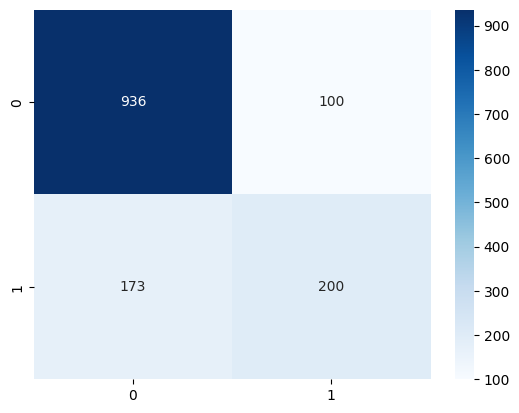

In [106]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# **Código para calcular las métricas de los modelos**

In [107]:
# Primero importa las métricas:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# **Métricas para Regresión Logística**

In [108]:
print("=== REGRESIÓN LOGÍSTICA ===")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_lr))

=== REGRESIÓN LOGÍSTICA ===
Accuracy: 0.8062455642299503
Precision: 0.6666666666666666
Recall: 0.5361930294906166
F1 Score: 0.5943536404160475

Matriz de Confusión:
[[936 100]
 [173 200]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1036
         1.0       0.67      0.54      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



# **Métricas para Árbol de Decisión**

In [109]:
print("=== ÁRBOL DE DECISIÓN ===")

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_tree))

=== ÁRBOL DE DECISIÓN ===
Accuracy: 0.7381121362668559
Precision: 0.5054054054054054
Recall: 0.5013404825737265
F1 Score: 0.5033647375504711

Matriz de Confusión:
[[853 183]
 [186 187]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82      1036
         1.0       0.51      0.50      0.50       373

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



# **Gráfica de matriz de confusión**

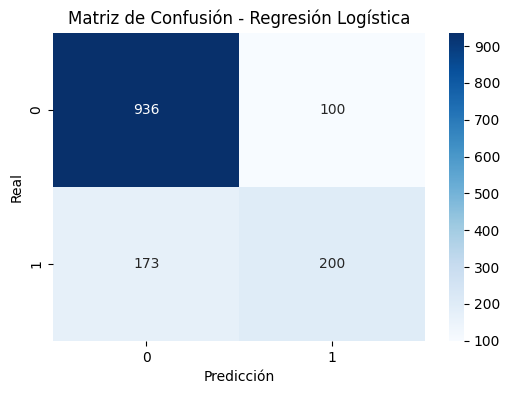

In [113]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# **Análisis de las métricas**

---



**Evaluación de modelos**

Se evaluaron los modelos de Regresión Logística y Árbol de Decisión utilizando diferentes métricas de desempeño: exactitud (accuracy), precisión, recall y F1-score, además de la matriz de confusión.

La métrica accuracy indica el porcentaje total de predicciones correctas realizadas por el modelo. Sin embargo, en problemas de clasificación como la predicción de cancelación de clientes, también es importante considerar métricas como precision y recall, ya que permiten evaluar qué tan bien el modelo identifica a los clientes que realmente cancelan el servicio.

El recall es particularmente importante en este contexto, ya que mide la capacidad del modelo para detectar correctamente a los clientes que tienen riesgo de cancelar el servicio. Detectar estos clientes es fundamental para que la empresa pueda aplicar estrategias de retención.

El F1-score combina precision y recall en una sola métrica, proporcionando una visión más equilibrada del desempeño del modelo.

La matriz de confusión permite observar con mayor detalle cuántos clientes fueron correctamente clasificados y cuántos fueron clasificados de manera incorrecta, diferenciando entre verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

# 📋 **Interpretación y Conclusiones**

---



# **Importancia de variables — Regresión Logística**

La regresión logística permite ver qué variables influyen más en la cancelación mediante los coeficientes del modelo.

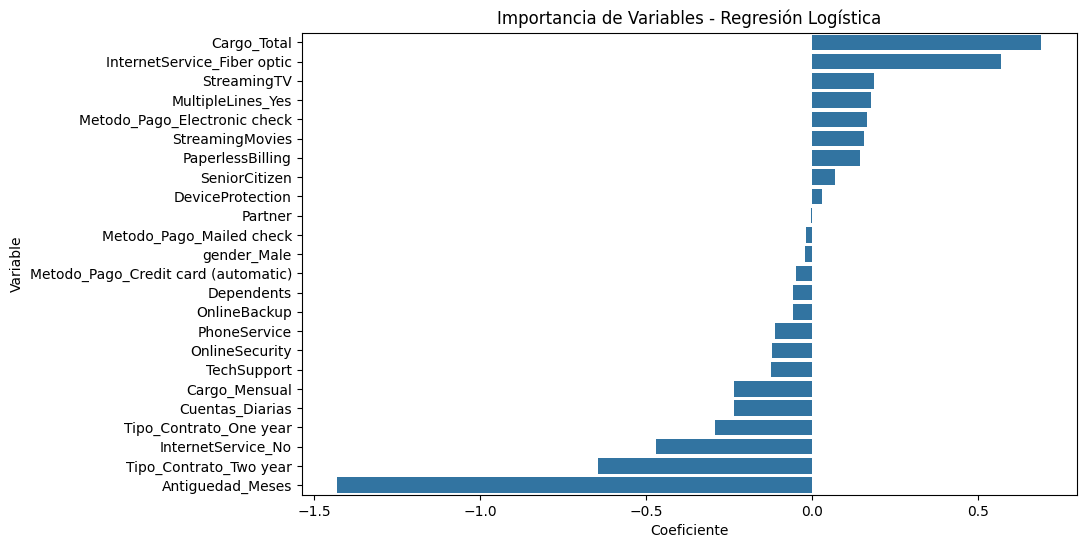

In [115]:
plt.figure(figsize=(10,6))
sns.barplot(x="Coeficiente", y="Variable", data=coeficientes)
plt.title("Importancia de Variables - Regresión Logística")
plt.show()

**Interpretación:**

* **Coeficiente positivo →** aumenta probabilidad de churn

* **Coeficiente negativo →** reduce probabilidad de churn

# I**nterpretación de variables relevantes**

---



**Análisis de variables relevantes**

A partir de los modelos construidos se analizaron las variables que tienen mayor influencia en la predicción de la cancelación de clientes. En el caso de la Regresión Logística, los coeficientes permiten identificar qué variables aumentan o disminuyen la probabilidad de churn. Por su parte, el Árbol de Decisión permite identificar la importancia de cada variable en las divisiones realizadas durante el entrenamiento del modelo.

* Entre las variables más influyentes se encuentran el tipo de contrato, la antigüedad del cliente, el cargo mensual y el tipo de servicio de internet. Por ejemplo, los clientes con menor antigüedad presentan una mayor probabilidad de cancelar el servicio, lo cual sugiere que los primeros meses de relación con la empresa son un periodo crítico para la retención.

* Asimismo, los clientes con contratos de corto plazo o sin contrato a largo plazo tienden a cancelar con mayor frecuencia que aquellos que tienen contratos de uno o dos años. Esto indica que los contratos más largos contribuyen a la estabilidad y permanencia del cliente.

* También se observa que los clientes con cargos mensuales más altos presentan mayor probabilidad de cancelación, lo cual podría estar relacionado con la percepción de costo elevado del servicio o con la competencia en el mercado.

# **Factores que influyen en la cancelación**

---

**Factores principales que influyen en la cancelación**

A partir del análisis exploratorio y de los modelos predictivos se identificaron varios factores clave asociados a la cancelación de clientes:

* **Baja antigüedad del cliente: **los clientes nuevos tienen mayor probabilidad de cancelar.

* **Tipo de contrato:** los contratos mensuales presentan mayor churn que los contratos anuales o de dos años.

* **Cargo mensual elevado:** los clientes con mayores costos mensuales muestran mayor tendencia a cancelar.

* **Tipo de servicio de internet:** ciertos tipos de servicio presentan mayor tasa de cancelación.

* **Método de pago: **algunos métodos de pago, como el pago electrónico, muestran mayor asociación con la cancelación.



# **Estrategias de retención basadas en resultados**

---

Con base en los resultados obtenidos, la empresa Telecom X podría implementar diversas estrategias para reducir la cancelación de clientes:

* **Programas de fidelización para clientes nuevos**, especialmente durante los primeros meses de servicio, que es cuando existe mayor riesgo de cancelación.

* **Incentivar contratos a largo plazo,** ofreciendo descuentos o beneficios adicionales para clientes que opten por contratos de uno o dos años.

* **Revisar la estructura de precios,** especialmente para clientes con cargos mensuales elevados, buscando mejorar la percepción de valor del servicio.

* **Fortalecer el soporte técnico y la experiencia del cliente**, ya que la satisfacción con el servicio influye directamente en la permanencia.

* **Implementar modelos predictivos en producción**, que permitan identificar clientes con alto riesgo de cancelación y aplicar acciones preventivas de retención.




# **Visualizaciones finales del análisis**

---

Para complementar el análisis del modelo predictivo, se presentan algunas visualizaciones que permiten comprender mejor los factores asociados a la cancelación de clientes. Estas gráficas ayudan a interpretar los resultados obtenidos por los modelos de machine learning y a identificar patrones relevantes en los datos.

Las visualizaciones muestran la importancia de las variables en la predicción, así como la relación entre características clave de los clientes —como la antigüedad y los cargos mensuales— y la probabilidad de cancelación.


**Importancia de variables del modelo**

Esta gráfica muestra qué variables influyen más en la predicción.

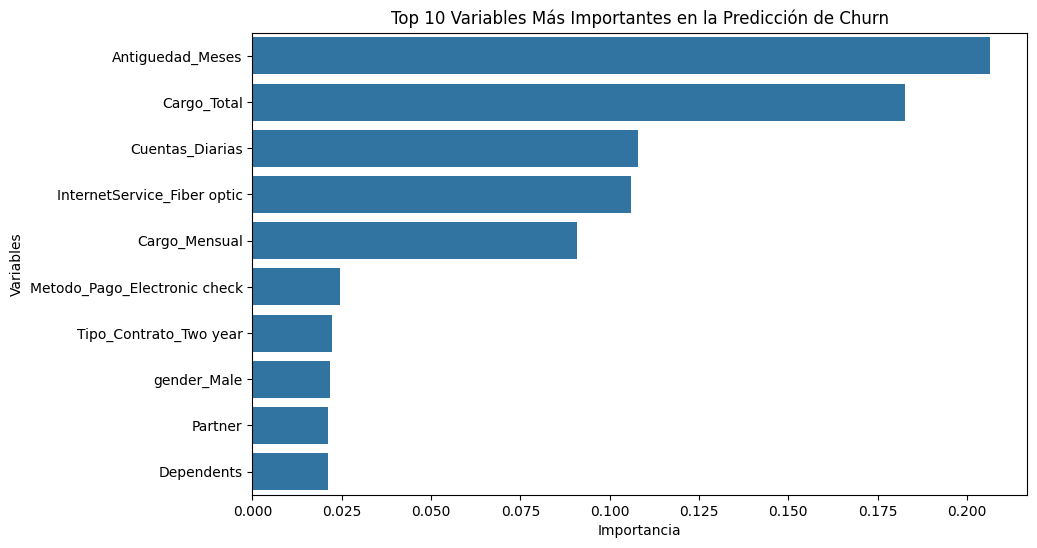

In [119]:
 importancia = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": model_tree.feature_importances_
})

importancia = importancia.sort_values(by="Importancia", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=importancia, x="Importancia", y="Variable")
plt.title("Top 10 Variables Más Importantes en la Predicción de Churn")
plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.show()

Esta gráfica permite identificar rápidamente qué factores explican más la cancelación.

**Distribución de antigüedad según cancelación**

Esta gráfica resume uno de los hallazgos más importantes del análisis.

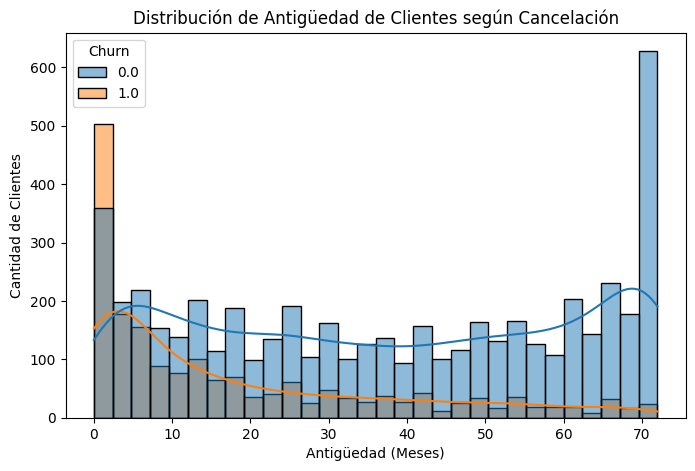

In [120]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Antiguedad_Meses", hue="Churn", bins=30, kde=True)

plt.title("Distribución de Antigüedad de Clientes según Cancelación")
plt.xlabel("Antigüedad (Meses)")
plt.ylabel("Cantidad de Clientes")

plt.show()

Interpretación típica:

* clientes con menor antigüedad cancelan más
* clientes con mayor permanencia permanecen

**Cargo mensual vs cancelación**

Esto muestra cómo el precio puede influir en el churn.

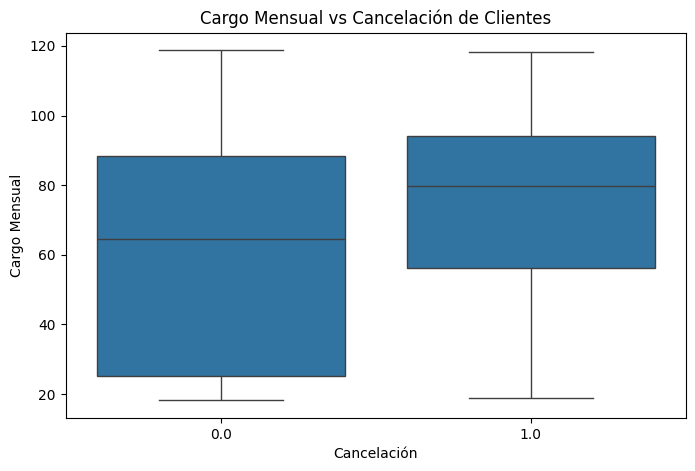

In [121]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="Cargo_Mensual", data=df)

plt.title("Cargo Mensual vs Cancelación de Clientes")
plt.xlabel("Cancelación")
plt.ylabel("Cargo Mensual")

plt.show()

Interpretación:

* clientes que cancelan suelen tener cargos mensuales más altos.

**Probabilidad de cancelación según tipo de contrato**

Esta gráfica muestra qué tipo de contrato tiene mayor tasa de cancelación.

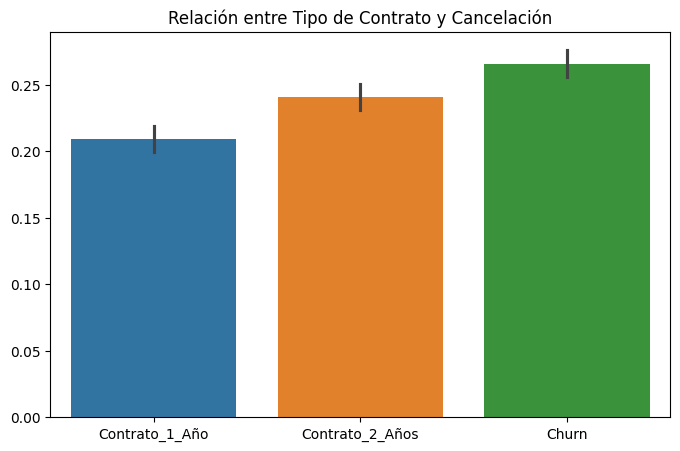

In [127]:
contrato = pd.DataFrame({
    "Contrato_1_Año": df["Tipo_Contrato_One year"],
    "Contrato_2_Años": df["Tipo_Contrato_Two year"],
    "Churn": df["Churn"]
})

plt.figure(figsize=(8,5))

sns.barplot(data=contrato)

plt.title("Relación entre Tipo de Contrato y Cancelación")
plt.show()

**Relación entre tipo de contrato y cancelación**

La visualización muestra que el tipo de contrato tiene una influencia significativa en la cancelación de clientes. Los clientes con contratos de mayor duración, como contratos de uno o dos años, tienden a presentar menores tasas de cancelación en comparación con aquellos que cuentan con contratos de corto plazo o mensuales.

Este resultado sugiere que los contratos de mayor duración generan una relación más estable entre el cliente y la empresa, reduciendo la probabilidad de abandono del servicio.

## **Conclusión final del proyecto**

---

En este proyecto se desarrolló un modelo de análisis y predicción de cancelación de clientes para la empresa Telecom X. A través del análisis exploratorio, la preparación de datos y la construcción de modelos de machine learning, fue posible identificar los principales factores asociados al churn.

Los resultados muestran que variables como la antigüedad del cliente, el tipo de contrato, los cargos mensuales y ciertas características del servicio tienen un impacto significativo en la probabilidad de cancelación. Además, los modelos predictivos permiten anticipar qué clientes presentan mayor riesgo de abandonar el servicio.

Este tipo de análisis permite a las empresas tomar decisiones basadas en datos y diseñar estrategias de retención más efectivas, reduciendo la pérdida de clientes y mejorando la estabilidad del negocio.
